[[[0.76923077 0.51126516]
  [0.76923077 0.51126516]
  [0.76923077 0.51126516]
  ...
  [0.76923077 0.51126516]
  [0.76923077 0.51126516]
  [0.76923077 0.51126516]]

 [[0.76923077 0.51126516]
  [0.76923077 0.51126516]
  [0.76923077 0.51126516]
  ...
  [0.76923077 0.51126516]
  [0.76923077 0.51126516]
  [0.76923077 0.51126516]]

 [[0.76923077 0.51126516]
  [0.76923077 0.51126516]
  [0.76923077 0.51126516]
  ...
  [0.76923077 0.51126516]
  [0.76923077 0.51126516]
  [0.76923077 0.51126516]]

 ...

 [[0.         0.        ]
  [0.         0.        ]
  [0.         0.        ]
  ...
  [0.         0.        ]
  [0.         0.        ]
  [0.         0.        ]]

 [[0.         0.        ]
  [0.         0.        ]
  [0.         0.        ]
  ...
  [0.         0.        ]
  [0.         0.        ]
  [0.         0.        ]]

 [[0.         0.        ]
  [0.         0.        ]
  [0.         0.        ]
  ...
  [0.         0.        ]
  [0.         0.        ]
  [0.         0.        ]]]


c:\Users\karth\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 50)         │        10,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,101 (125.39 KB)

 Trainable params: 32,101 (125.39 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - loss: 0.0267 - val_loss: 0.0012
Epoch 2/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.0022 - val_loss: 7.5946e-04
Epoch 3/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.0016 - val_loss: 0.0027
Epoch 4/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.0011 - val_loss: 0.0011
Epoch 5/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 9.2211e-04 - val_loss: 0.0039
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
RMSE: 0.01


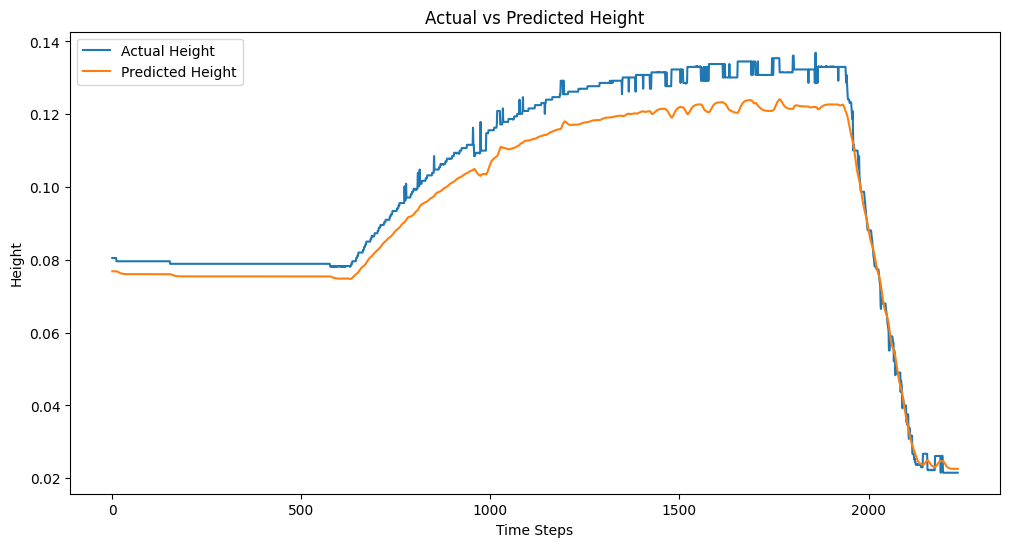

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dense, Dropout
from keras import Sequential
from keras.layers import LSTM, Dense, Dropout # type: ignore

# Load your dataset
# df = pd.read_csv("/content/exp_dataset.csv")
df = pd.read_csv(r"C:\Users\karth\Downloads\Real System_data_OL_2025-02-14_20-37-49.csv")

# Preprocessing
data = df[['voltage', 'height']].values  # Voltage = u, Height = y

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Create sequences for LSTM
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])  # Include Voltage and Height
        y.append(data[i+sequence_length, 1])  # Future Height (y)
    return np.array(X), np.array(y)

sequence_length = 30  # Number of time steps in each sequence
X, y = create_sequences(scaled_data, sequence_length)

# Reshape X for LSTM (samples, time steps, features)
X = X.reshape((X.shape[0], sequence_length, 2))  # 2 features: Voltage and Height

# Split into training and testing sets
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(X_test)

# Build the LSTM model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(sequence_length, 2)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25, activation='relu'),
    Dense(1)  # Single output for Height (y)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
                    epochs=5, batch_size=32, verbose=1)

# Predict and inverse transform the data
predictions = model.predict(X_test)
scaled_predictions = np.zeros((len(predictions), 2))
scaled_predictions[:, 1] = predictions[:, 0]  # Only Height (y) is predicted
predictions = scaler.inverse_transform(scaled_predictions)[:, 1]

# Rescale y_test for comparison
scaled_y_test = np.zeros((len(y_test), 2))
scaled_y_test[:, 1] = y_test
y_test_rescaled = scaler.inverse_transform(scaled_y_test)[:, 1]

# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test_rescaled, predictions))
print(f"RMSE: {rmse:.2f}")

# Visualization
plt.figure(figsize=(12, 6))
plt.plot(y_test_rescaled, label='Actual Height')
plt.plot(predictions, label='Predicted Height')
plt.legend()
plt.xlabel('Time Steps')
plt.ylabel('Height')
plt.title('Actual vs Predicted Height')
plt.show()


In [3]:
model.save('trained_model.h5')
import joblib
joblib.dump(scaler, "scaler.pkl")  # Save the scaler to a file

['scaler.pkl']